In [1]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

import parcels

/var/folders/1n/500ln6w97859_nqq86vwpl000000gr/T/ipykernel_59901/3847280476.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
df = parcels.read_particlefile("Simulations/Simulation_Satellite_kN_0.001.parquet")

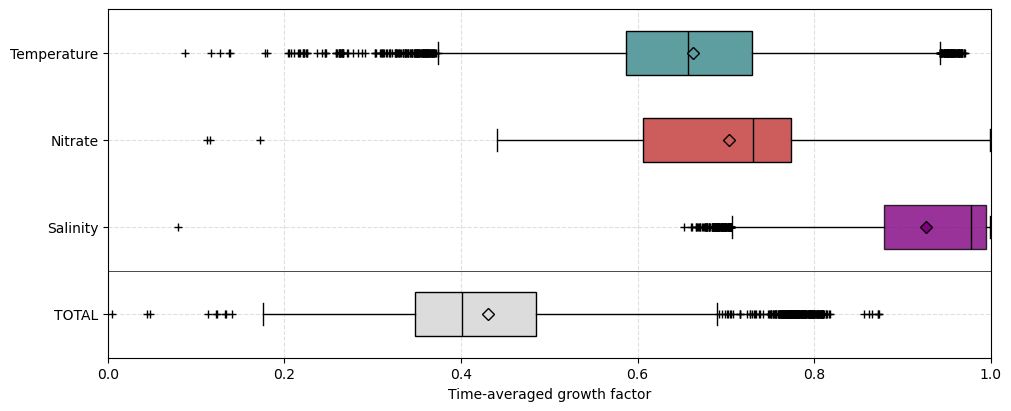

In [3]:
plt.figure(figsize=(10, 4), constrained_layout=True)

vars = ['limitation', 'lim_salinity', 'lim_nitrogen', 'lim_temperature']
limitation_names = ['TOTAL', 'Salinity', 'Nitrate', 'Temperature']
colors = ['gainsboro', 'purple' , 'indianred', 'cadetblue']
alphas = [1, 0.8, 1, 1]

last_time = df.select(pl.col("time").max()).item()
df_reaching_last_time = df.filter(
    pl.col("time").max().over("particle_id") == last_time
)

for i, var in enumerate(vars):
    data = (
        df_reaching_last_time
        .group_by("particle_id")
        .agg(pl.col(var).drop_nans().mean().alias(var))
        .get_column(var)
        .to_numpy()
    )

    plt.boxplot(
        data[~np.isnan(data)],
        positions=[i],
        widths=0.5,
        patch_artist=True,
        orientation='horizontal',
        boxprops=dict(facecolor=colors[i], alpha=alphas[i]),
        medianprops=dict(color='black'),
        showmeans=True,
        meanprops = dict(marker='D',markeredgecolor='black', markerfacecolor=colors[i]),
        sym='+',
    )

plt.yticks(range(4) , limitation_names, rotation=0)
plt.xlabel('Time-averaged growth factor')
plt.xlim(0, 1)
plt.hlines(0.5, 0, 1, colors='black', linewidth=0.5)
plt.grid( linestyle='--', alpha=0.4)
plt.savefig('Figures/Figure4.pdf', bbox_inches='tight', dpi=300)
plt.show()